# **Load processed data**

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed_dataset.csv")

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# **Train-test split**

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **Model Training**

## Random Forest

In [3]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

## Decision Tree

In [4]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

## Logistic Regression

In [5]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

## SVM

In [6]:
from sklearn.svm import SVC

svm = SVC(random_state=42)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

# **Evaluation**

In [7]:
from sklearn.metrics import classification_report, accuracy_score

print("RF:\n", classification_report(y_test, rf_pred))
print("DT:\n", classification_report(y_test, dt_pred))
print("LR:\n", classification_report(y_test, lr_pred))
print("SVM:\n", classification_report(y_test, svm_pred))

RF:
                  precision    recall  f1-score   support

        crazing       0.80      0.83      0.81        53
      inclusion       0.75      0.69      0.72        74
        patches       0.96      0.93      0.94        55
 pitted_surface       0.87      0.78      0.82        50
rolled-in_scale       0.67      0.79      0.72        68
      scratches       0.71      0.68      0.69        60

       accuracy                           0.78       360
      macro avg       0.79      0.78      0.79       360
   weighted avg       0.78      0.78      0.78       360

DT:
                  precision    recall  f1-score   support

        crazing       0.63      0.68      0.65        53
      inclusion       0.72      0.78      0.75        74
        patches       0.85      0.95      0.90        55
 pitted_surface       0.64      0.56      0.60        50
rolled-in_scale       0.78      0.63      0.70        68
      scratches       0.57      0.60      0.59        60

       accuracy 

# **Confusion Matrix**

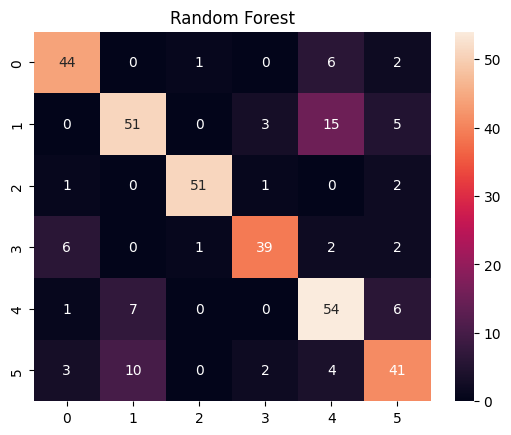

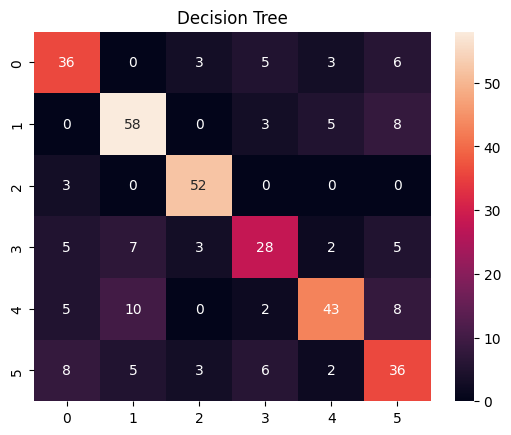

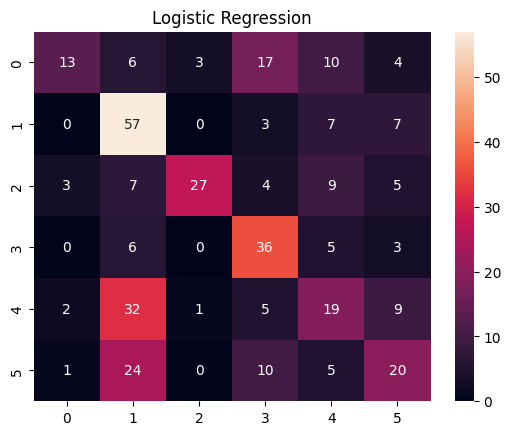

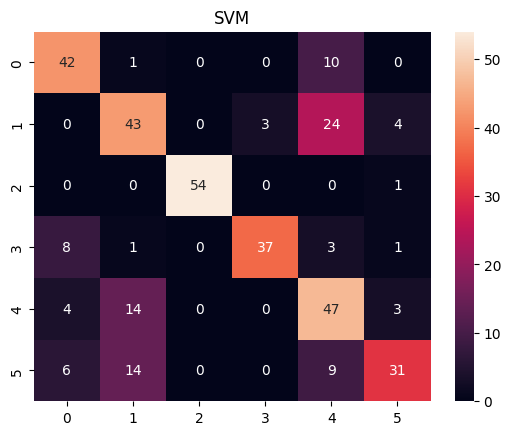

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(title)
    plt.show()

plot_cm(y_test, rf_pred, "Random Forest")
plot_cm(y_test, dt_pred, "Decision Tree")
plot_cm(y_test, lr_pred, "Logistic Regression")
plot_cm(y_test, svm_pred, "SVM")

# **Model Comparison**


In [9]:
results = {
    "Random Forest": accuracy_score(y_test, rf_pred),
    "Decision Tree": accuracy_score(y_test, dt_pred),
    "Logistic Regression": accuracy_score(y_test, lr_pred),
    "SVM": accuracy_score(y_test, svm_pred)
}

import pandas as pd

results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
results_df

,Model,Accuracy
0,Random Forest,0.777778
1,Decision Tree,0.702778
2,Logistic Regression,0.477778
3,SVM,0.705556


# **Plot Comparison**

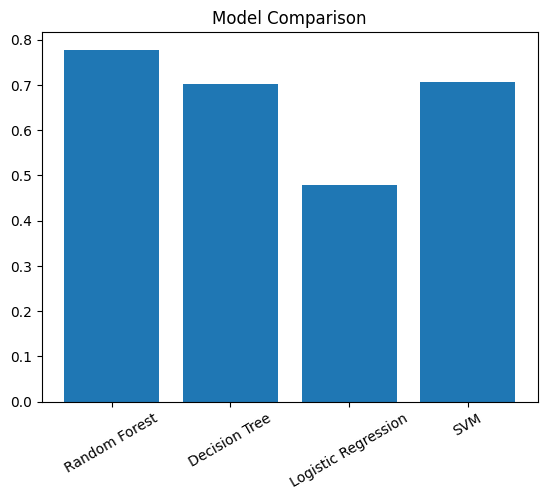

In [10]:
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xticks(rotation=30)
plt.title("Model Comparison")
plt.show()

# **Feature Importance**

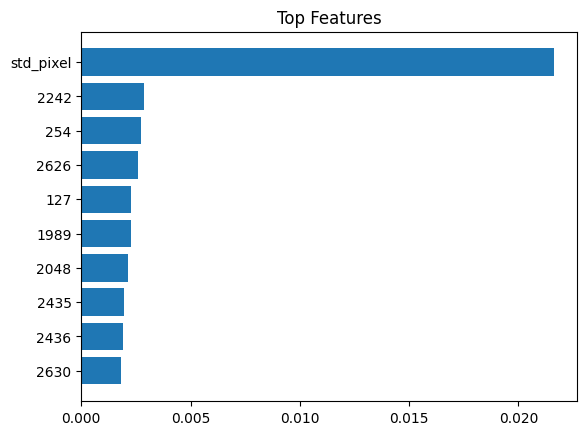

In [11]:
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)[-10:]

plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.title("Top Features")
plt.show()

# **Save Model**


In [12]:
import joblib
joblib.dump(rf, "../models/model.pkl")

['../models/model.pkl']

## Conclusion

In this project, we developed a machine learning-based system for detecting surface defects in manufacturing images.

We performed data preprocessing, exploratory data analysis, and feature engineering to prepare the dataset. Multiple machine learning models such as Random Forest, Decision Tree, Logistic Regression, and SVM were trained and evaluated.

Among these, the best-performing model was selected based on accuracy and evaluation metrics. The model was further interpreted using feature importance techniques.

Finally, the system was deployed using Streamlit, enabling real-time defect detection through image upload.

This project demonstrates how machine learning can improve efficiency, accuracy, and scalability in industrial quality control processes.